In [1]:
import google.auth
credentials, PROJECT_ID= google.auth.default()
print(credentials)
print(PROJECT_ID)

anbc-hcb-dev


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_komodo_Feb_2024_June_2023_embeddings` 
"""
kmdo = client.query(sql).to_dataframe() 
kmdo.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,0.168402,-0.555751,-0.660623,0.303930,-0.149092,0.890989,-0.977375,-0.621689,0.474697,-0.848119,...,0.093335,0.290505,-0.934549,-1.014390,0.569241,1.045858,-0.229129,-1.053697,-0.133433,451414613
1,-0.416256,-0.700537,-0.783972,-0.052708,-0.370296,1.332878,-0.720160,-0.597772,0.187729,-0.580553,...,0.263446,-0.024314,-0.498963,-0.858891,1.311380,-0.231069,-0.242277,-0.812001,-0.847878,440699379
2,0.031960,-0.558897,-0.579486,0.290968,-0.304750,0.813385,-0.682312,-0.927591,0.509329,-0.816224,...,0.056245,0.353387,-1.140309,-1.166346,1.385108,0.969513,-0.210503,-1.119490,-0.467472,451403970
3,-0.897389,-0.540291,-0.772539,0.004815,-0.532597,0.901281,-0.633877,-0.964642,0.462234,-0.677313,...,0.421268,-0.054203,-0.488216,-0.912997,0.982522,0.439394,-0.032556,-0.750645,-0.811749,510295026
4,-0.103579,0.083848,-0.923162,0.055697,-0.093998,0.723451,-1.010912,-0.938975,0.490859,-0.844108,...,0.734285,0.413765,-0.500784,-1.078886,0.698441,0.427916,-0.419233,-1.091432,-0.243776,520350686


In [10]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_tenure` 
"""
tenure = client.query(sql).to_dataframe() 
tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
0,480242035,48,VA,2023-06-01,DD,ABD,13
1,480254667,48,VA,2023-06-01,DD,ABD,13
2,480612110,48,VA,2023-06-01,DD,ABD,5
3,480409088,48,VA,2023-06-01,DD,ABD,13
4,480268205,48,VA,2023-06-01,DD,ABD,13


In [12]:
tenure = tenure.rename(columns={"asdb_member_key": "individual_id"})
tenure = tenure.set_index('individual_id')

In [46]:
kmdo_mem = tenure.merge(kmdo, on='individual_id', how='left')
kmdo_mem = kmdo_mem.assign(embed_type = 'komodo_integrated')
kmdo_mem.fillna(value = 0, inplace = True)

In [8]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcomes_revised` 
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.head()

,asdb_member_key,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,451273819,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
1,331866516,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
2,72770364,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
3,590160596,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
4,500412560,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0


In [47]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_mem.merge(outcomes, on='individual_id', how='left')

In [13]:
pd.crosstab(tenure['tenure'], tenure['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [48]:
pd.crosstab(kmdo_outcome['tenure'], kmdo_outcome['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [49]:
kmdo_outcome.columns.values.tolist()

['individual_id',
 'asdb_plan_key',
 'asdb_plan_nm',
 'asdb_elig_dt',
 'coa_population_category',
 'coa_population_group',
 'tenure',
 'emb0',
 'emb1',
 'emb2',
 'emb3',
 'emb4',
 'emb5',
 'emb6',
 'emb7',
 'emb8',
 'emb9',
 'emb10',
 'emb11',
 'emb12',
 'emb13',
 'emb14',
 'emb15',
 'emb16',
 'emb17',
 'emb18',
 'emb19',
 'emb20',
 'emb21',
 'emb22',
 'emb23',
 'emb24',
 'emb25',
 'emb26',
 'emb27',
 'emb28',
 'emb29',
 'emb30',
 'emb31',
 'emb32',
 'emb33',
 'emb34',
 'emb35',
 'emb36',
 'emb37',
 'emb38',
 'emb39',
 'emb40',
 'emb41',
 'emb42',
 'emb43',
 'emb44',
 'emb45',
 'emb46',
 'emb47',
 'emb48',
 'emb49',
 'emb50',
 'emb51',
 'emb52',
 'emb53',
 'emb54',
 'emb55',
 'emb56',
 'emb57',
 'emb58',
 'emb59',
 'emb60',
 'emb61',
 'emb62',
 'emb63',
 'emb64',
 'emb65',
 'emb66',
 'emb67',
 'emb68',
 'emb69',
 'emb70',
 'emb71',
 'emb72',
 'emb73',
 'emb74',
 'emb75',
 'emb76',
 'emb77',
 'emb78',
 'emb79',
 'emb80',
 'emb81',
 'emb82',
 'emb83',
 'emb84',
 'emb85',
 'emb86',
 'emb8

In [16]:
#kmdo_outcome.fillna(value = 0, inplace = True)
kmdo_outcome.head()

,individual_id,asdb_plan_key_x,asdb_plan_nm_x,asdb_elig_dt_x,coa_population_category_x,coa_population_group_x,emb0,emb1,emb2,emb3,...,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable,asdb_plan_key_y,asdb_plan_nm_y,asdb_elig_dt_y,coa_population_category_y,coa_population_group_y,tenure
0,480248210,48,VA,2023-06-01,DD,ABD,0.437266,-0.892022,-0.134072,-0.042579,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
1,480183630,48,VA,2023-06-01,DD,ABD,-0.608172,-0.421894,-0.949537,0.303980,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
2,480249646,48,VA,2023-06-01,DD,ABD,-0.456634,-0.512235,-0.505720,-0.050555,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
3,480236900,48,VA,2023-06-01,DD,ABD,-0.317939,-0.766088,-0.715321,-0.058599,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
4,480239602,48,VA,2023-06-01,DD,ABD,-0.444804,-1.120099,-0.613433,0.364074,...,1,1,1,0,48,VA,2023-06-01,DD,ABD,13


In [17]:
print(kmdo_outcome['acute_ip_flag'].value_counts())

0    2802354
1      46029
Name: acute_ip_flag, dtype: Int64


In [50]:
kmdo_outcome = kmdo_outcome.set_index('individual_id')

In [67]:
print(tenure['coa_population_category'].value_counts())

TANF                     1427393
Expansion                 731116
ABD Non Dual Non LTSS     144252
CHIP                      139495
BH Only                    78206
Dual Elig NonLTSS          70434
Foster                     66874
Dual Int NonLTSS           44480
Dual Elig LTSS             40321
BH Int SMI                 40245
Dual Int LTSS              17913
ABD Non Dual LTSS          15558
DD                         14623
LTSS Only                   7993
DSNP Medicare Only          6986
Dual Int DD                 1878
Other                        616
Name: coa_population_category, dtype: int64


In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(X['coa_population_category'])
LabelEncoder()
list(le.classes_)
kmdo_outcome['coa_transformed'] = le.transform(X['coa_population_category'])
#list(le.inverse_transform([2, 2, 1]))
#list(le.inverse_transform([5, 5, 5]))
kmdo_outcome.head()

,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure,emb0,emb1,emb2,emb3,...,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable,coa_transformed
individual_id,,,,,,,,,,,,,,,,,,,,,
480242035,48,VA,2023-06-01,DD,ABD,13,-0.077770,-0.798805,-0.634205,-0.048983,...,0,0.0,0,0.0,1,1,0,0,0,5
480254667,48,VA,2023-06-01,DD,ABD,13,-0.240400,-0.503098,-0.710351,0.289905,...,0,0.0,0,0.0,0,0,0,0,0,5
480612110,48,VA,2023-06-01,DD,ABD,5,-0.555494,-0.450667,-0.758921,0.006313,...,0,0.0,0,0.0,1,1,0,0,0,5
480409088,48,VA,2023-06-01,DD,ABD,13,-0.584980,-0.992901,-0.630395,0.145485,...,0,0.0,0,0.0,0,0,0,0,0,5
480268205,48,VA,2023-06-01,DD,ABD,13,-0.158595,-0.565024,-0.608284,-0.466039,...,0,0.0,0,0.0,0,0,0,0,0,5


In [70]:
kmdo_outcome.shape

(2848383, 276)

In [75]:
pd.crosstab(kmdo_outcome['coa_population_category'], kmdo_outcome['coa_transformed'])

coa_transformed,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
coa_population_category,,,,,,,,,,,,,,,,,
ABD Non Dual LTSS,15558,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ABD Non Dual Non LTSS,0,144252,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BH Int SMI,0,0,40245,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BH Only,0,0,0,78206,0,0,0,0,0,0,0,0,0,0,0,0,0
CHIP,0,0,0,0,139495,0,0,0,0,0,0,0,0,0,0,0,0
DD,0,0,0,0,0,14623,0,0,0,0,0,0,0,0,0,0,0
DSNP Medicare Only,0,0,0,0,0,0,6986,0,0,0,0,0,0,0,0,0,0
Dual Elig LTSS,0,0,0,0,0,0,0,40321,0,0,0,0,0,0,0,0,0
Dual Elig NonLTSS,0,0,0,0,0,0,0,0,70434,0,0,0,0,0,0,0,0


In [72]:
#split dataset in features and target variable
X = kmdo_outcome.iloc[:, np.r_[5:262, 275]] # Features df.iloc[:, np.r_[0, 2, 4:9]]
y = kmdo_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,tenure,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,coa_transformed
individual_id,,,,,,,,,,,,,,,,,,,,,
480242035,13,-0.077770,-0.798805,-0.634205,-0.048983,-0.048494,0.801673,-0.616467,-0.067412,0.154925,...,-0.143426,0.166442,-0.385184,-0.688404,0.942226,-0.076162,0.470185,-0.489971,-0.674293,5
480254667,13,-0.240400,-0.503098,-0.710351,0.289905,-0.387002,1.323509,-0.783442,-0.574817,-0.078163,...,0.222538,-0.254701,-1.079591,-0.873189,0.792047,0.171935,-0.223123,-0.715617,-0.581367,5
480612110,5,-0.555494,-0.450667,-0.758921,0.006313,-0.094488,0.637128,-0.495281,0.026685,0.576161,...,0.229505,-0.082863,-0.602523,-0.705908,0.986503,-0.322444,0.159278,-0.286643,-0.642393,5
480409088,13,-0.584980,-0.992901,-0.630395,0.145485,-0.802408,0.854497,-0.605468,-0.218705,0.266885,...,0.410289,-0.016448,-0.502469,-1.081226,0.927799,0.038497,0.301528,-0.787003,-0.577370,5
480268205,13,-0.158595,-0.565024,-0.608284,-0.466039,-0.394955,0.471751,-0.287645,-0.290283,-0.027976,...,0.120452,-0.377964,-0.484865,-0.670835,0.772973,-0.424862,-0.400232,-0.734806,-0.440172,5


In [73]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [74]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [76]:
y_pred = logreg.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(712096, 1)

In [84]:
threshold = 0.17

y_predict_prob =logreg.predict_proba(X_test)[:, 1]
y_predict_lab = ((logreg.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,693683,7085
1,8829,2499


In [85]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[693683,   7085],
       [  8829,   2499]])

Text(0.5, 427.9555555555555, 'Predicted label')

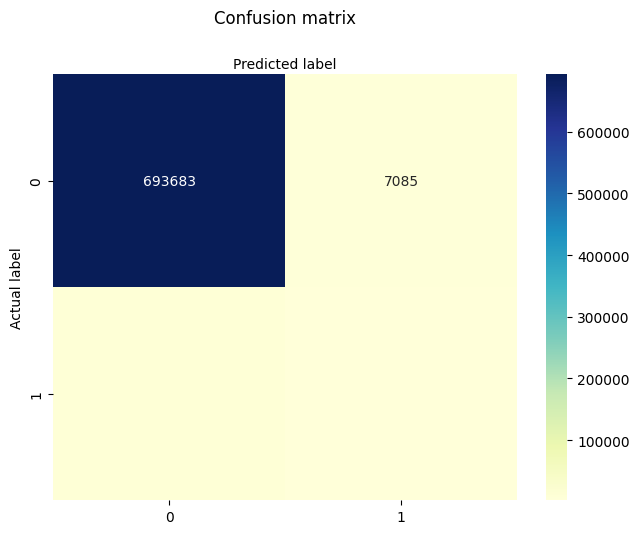

In [86]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [87]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      0.99      0.99    700768
     with IP       0.26      0.22      0.24     11328

    accuracy                           0.98    712096
   macro avg       0.62      0.61      0.61    712096
weighted avg       0.98      0.98      0.98    712096



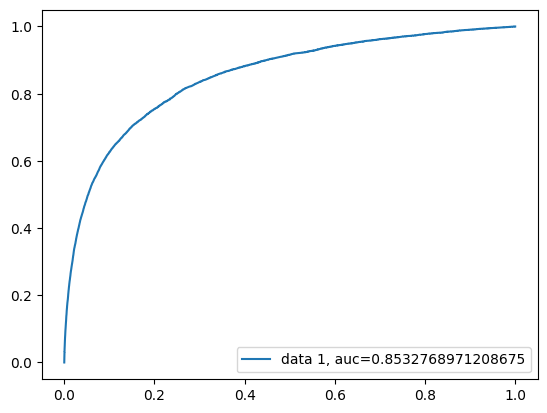

In [88]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

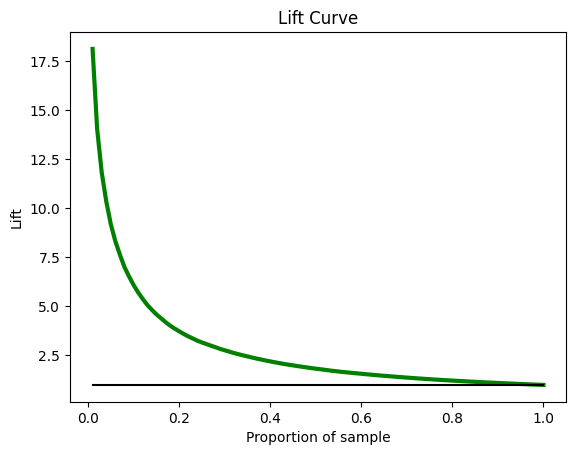

In [89]:
# Function that plots a Lift Curve using the real label values of a dataset and the probability predictions of a Machine Learning Algorithm/model
# @Params:
# y_val: real labels of the data
# y_pred: probability predictions for such data
# step: how big we want the steps in the percentiles to be

# imports
import numpy as np
import pandas as pd

def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_proba, step=0.01)

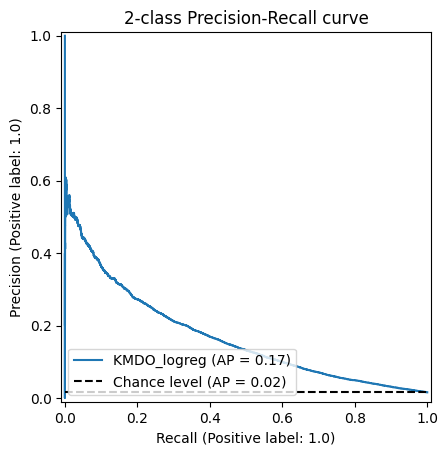

In [90]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    logreg, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [91]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [92]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.686095,0.198425,2052,7121,1.000006,18.114407,18.114407,1.000006,18.114305
1,0.198425,0.134953,1130,7121,1.000006,9.975282,28.089689,2.000011,14.044766
2,0.134946,0.102757,840,7121,1.000006,7.415254,35.504944,3.000017,11.834915
3,0.102737,0.082461,671,7121,1.000006,5.923376,41.428319,4.000022,10.357022
4,0.082459,0.068647,511,7121,1.000006,4.510946,45.939266,5.000028,9.187801
...,...,...,...,...,...,...,...,...,...
95,0.001375,0.001307,11,7121,1.000006,0.097105,99.629237,95.999978,1.037805
96,0.001307,0.001231,9,7121,1.000006,0.079449,99.708686,96.999983,1.027925
97,0.001231,0.001143,11,7121,1.000006,0.097105,99.805791,97.999989,1.018427
98,0.001143,0.001018,10,7121,1.000006,0.088277,99.894068,98.999994,1.009031


In [93]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [96]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.686095,0.034842,6900,71210,10.000056,60.911017,60.911017,10.000056,6.091067
1,0.034842,0.015403,1554,71210,10.000056,13.71822,74.629237,20.000112,3.731441
2,0.015403,0.010047,946,71209,9.999916,8.350989,82.980226,30.000028,2.766005
3,0.010047,0.007183,559,71210,10.000056,4.934675,87.914901,40.000084,2.197868
4,0.007183,0.005337,389,71209,9.999916,3.433969,91.34887,50.000000,1.826977
5,0.005337,0.004025,313,71210,10.000056,2.763065,94.111935,60.000056,1.568531
6,0.004025,0.002989,227,71209,9.999916,2.003884,96.115819,69.999972,1.373084
7,0.002989,0.002260,175,71210,10.000056,1.544845,97.660664,80.000028,1.220758
8,0.002260,0.001676,155,71209,9.999916,1.368291,99.028955,89.999944,1.100322
9,0.001676,0.000072,110,71210,10.000056,0.971045,100.0,100.000000,1.0


In [95]:
df_out = pd.merge(y_pred, tenure, how = 'left',left_index = True, right_index = True)

In [98]:
df_out.shape
df_out.head()

,acute_ip_flag,y_predict_prob,y_predict_class,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,,,,
440648407,0,0.007794,0,44,WV,2023-06-01,TANF,TANF/CHIP,13
440426259,1,0.060849,0,44,WV,2023-06-01,TANF,TANF/CHIP,13
590103173,0,0.003211,0,59,KS,2023-06-01,CHIP,TANF/CHIP,13
451084335,0,0.001766,0,45,KY,2023-06-01,TANF,TANF/CHIP,13
440655984,0,0.002122,0,44,WV,2023-06-01,TANF,TANF/CHIP,13


In [108]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df    

In [109]:
lift_chart(df_out[df_out['tenure'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.686095,0.180813,107,466,1.001160,12.829736,12.829736,1.001160,12.814869
1,0.180722,0.113834,66,465,0.999012,7.913669,20.743405,2.000172,10.370811
2,0.113805,0.083233,43,466,1.001160,5.155875,25.899281,3.001332,8.629262
3,0.083212,0.065576,30,465,0.999012,3.597122,29.496403,4.000344,7.373467
4,0.065539,0.053320,24,466,1.001160,2.877698,32.374101,5.001504,6.472873
...,...,...,...,...,...,...,...,...,...
95,0.003382,0.003133,0,466,1.001160,0.0,99.160671,95.999656,1.032927
96,0.003133,0.002863,1,465,0.999012,0.119904,99.280576,96.998668,1.023525
97,0.002863,0.002557,2,466,1.001160,0.239808,99.520384,97.999828,1.015516
98,0.002556,0.002213,3,465,0.999012,0.359712,99.880096,98.998840,1.008902


In [110]:
lift_chart(df_out[df_out['tenure'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.638676,0.168261,177,733,1.001270,16.777251,16.777251,1.001270,16.755965
1,0.168155,0.109164,112,732,0.999904,10.616114,27.393365,2.001175,13.688642
2,0.108939,0.081325,65,732,0.999904,6.161137,33.554502,3.001079,11.180812
3,0.081315,0.064596,55,732,0.999904,5.21327,38.767773,4.000984,9.689561
4,0.064574,0.053660,56,732,0.999904,5.308057,44.075829,5.000888,8.813601
...,...,...,...,...,...,...,...,...,...
95,0.002052,0.001951,2,732,0.999904,0.189573,99.336493,95.999016,1.034766
96,0.001951,0.001830,1,732,0.999904,0.094787,99.43128,96.998921,1.025076
97,0.001830,0.001689,0,732,0.999904,0.0,99.43128,97.998825,1.014617
98,0.001689,0.001491,3,732,0.999904,0.28436,99.71564,98.998730,1.007242


In [111]:
lift_chart(df_out[df_out['tenure'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.653416,0.202725,1768,5924,1.000096,18.730798,18.730798,1.000096,18.728995
1,0.202690,0.138902,972,5923,0.999927,10.297701,29.028499,2.000024,14.514078
2,0.138891,0.106313,718,5924,1.000096,7.606738,36.635237,3.000120,12.211258
3,0.106312,0.085818,548,5923,0.999927,5.8057,42.440937,4.000047,10.610109
4,0.085817,0.071618,455,5924,1.000096,4.820426,47.261362,5.000143,9.452001
...,...,...,...,...,...,...,...,...,...
95,0.001322,0.001260,6,5924,1.000096,0.063566,99.618604,95.999953,1.037694
96,0.001260,0.001190,7,5923,0.999927,0.07416,99.692764,96.999880,1.027762
97,0.001190,0.001108,10,5924,1.000096,0.105943,99.798707,97.999976,1.018354
98,0.001108,0.000991,8,5923,0.999927,0.084755,99.883462,98.999904,1.008925


In [103]:
m0_3 = df_out.loc[df_out['tenure'].isin([0,1,2,3,])]
m4_8 = df_out.loc[df_out['tenure'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[df_out['tenure'].isin([9,10,11,12,13,])]

In [104]:
print("% admitted post 6 months ABD: ", m0_3['acute_ip_flag'].mean()*100)
print("% admitted post 6 months BH: ", m4_8['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Elig: ", m_9_13['acute_ip_flag'].mean()*100)

% admitted post 6 months ABD:  1.791775877626434
% admitted post 6 months BH:  1.4411190186730778
% admitted post 6 months Dual Elig:  1.5935024132977007


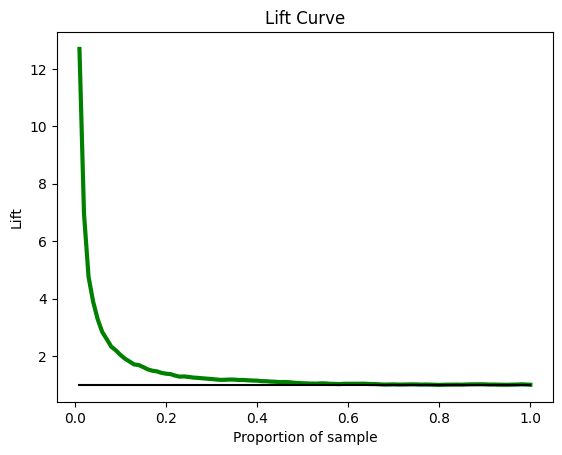

In [105]:
plot_lift_curve(m0_3['acute_ip_flag'], m0_3['y_predict_class'], step=0.01)

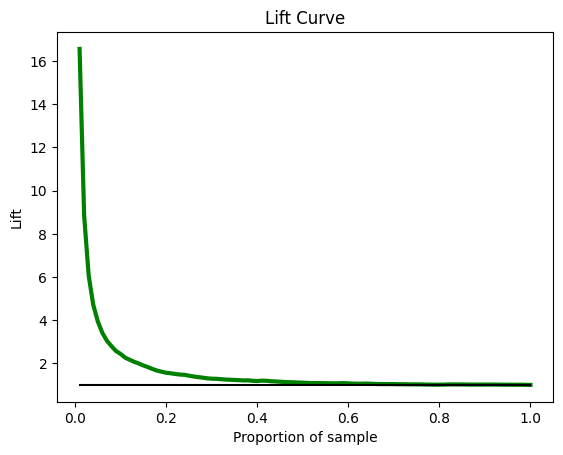

In [106]:
plot_lift_curve(m4_8['acute_ip_flag'], m4_8['y_predict_class'], step=0.01)

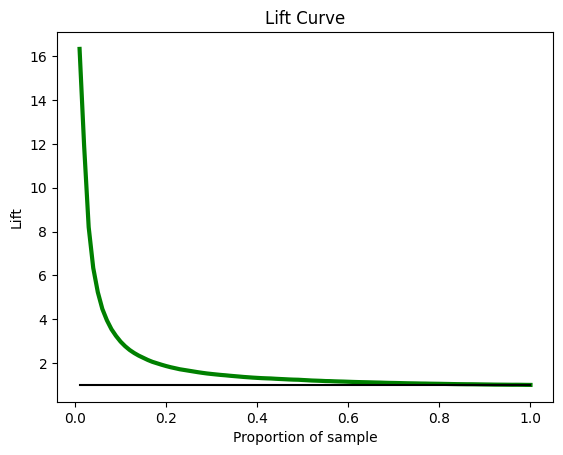

In [107]:
plot_lift_curve(m_9_13['acute_ip_flag'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
from joblib import dump, load
dump(logreg, 'Medicaid_IP_embeddings_only_logreg.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

In [ ]:
# create the data, or the data that is to be estimated
data = data.drop('TOTAL_DAYS_TO_COMPLETE', axis=1)

# Remove the order number since we don't need it
order_numbers = data['ORDER_NUMBER']
data = data.drop('ORDER_NUMBER', axis=1)

# # split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size = 0.2)

rf = RandomForestRegressor(
    bootstrap = True,
    max_depth = None,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 2,
    n_estimators  = 5000
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_differences = compare_values(y_test, rf_predictions)
rf_Avg = np.average(rf_differences)
print("#################################################")
print("DATA FOR RANDOM FORESTS")
print(rf_Avg)
importances = get_feature_importances(X_test.columns, rf.feature_importances_)
print()
print(importances)

res = y_test.to_frame('Actual Value')
res.insert(0, 'Predicted Value', rf_predictions)
res = order_numbers.to_frame().join(res, how='inner')
print(res)